# **1. Import Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer
import joblib

import sklearn
import yellowbrick

print(sklearn.__version__)
print(yellowbrick.__version__)

1.6.1
1.5


# **2. Load Dataset**

In [2]:
url = 'https://docs.google.com/spreadsheets/d/e/2PACX-1vTbg5WVW6W3c8SPNUGc3A3AL-AG32TPEQGpdzARfNICMsLFI0LQj0jporhsLCeVhkN5AoRsTkn08AYl/pub?output=csv'
df = pd.read_csv(url)

# Menampilkan 5 baris teratas
df.head()

,TransactionID,AccountID,TransactionAmount,PreviousTransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 8:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 8:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 8:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 8:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,198.0,1.0,7429.40,2024-11-04 8:06:39


# **3. EDA (Exploratory Data Analysis)**

In [3]:
# Menampilkan ringkasan data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2508 non-null   object 
 1   AccountID                2516 non-null   object 
 2   TransactionAmount        2511 non-null   float64
 3   PreviousTransactionDate  2509 non-null   object 
 4   TransactionType          2507 non-null   object 
 5   Location                 2507 non-null   object 
 6   DeviceID                 2507 non-null   object 
 7   IP Address               2517 non-null   object 
 8   MerchantID               2514 non-null   object 
 9   Channel                  2510 non-null   object 
 10  CustomerAge              2519 non-null   float64
 11  CustomerOccupation       2514 non-null   object 
 12  TransactionDuration      2511 non-null   float64
 13  LoginAttempts            2516 non-null   float64
 14  AccountBalance          

Berdasarkan ringkasan struktur atau metadata DataFrame diatas, jumlah kolom terdapat 16 kolom sedangkan untuk jumlah baris terdapat 2537 baris.
- **RangeIndex: 2537 entries, 0 to 2536** : terdapat 2537 baris dan jika dihitung berdasarkan index baris data ini terdapat 2536 (karena index berawal dari 0, bukan 1)
- **Column** : nama kolom
- **Non-Null Count** : jumlah baris suatu kolom
- **Dtype** : tipe data pada suatu kolom
- **dtypes: float64(5), str(11)** : terdapat 5 data float, 5 data string
<p style="text-align: justify; text-indent: 2em;">
<strong>Non-Null Count</strong> merupakan informasi jumlah baris pada suatu kolom. Contohnya pada kolom <code>TransactionID</code> 2508. Jumlah baris ini dibawah angka dari jumlah total baris yang ada pada data. Itu artinya di kolom <code>TransactionID</code> terdapat baris yang kosong. Cara menghitungnya secara manual dengan mengurangi jumlah total baris dengan jumlah baris suatu kolom (2537-2508 = 29). Berarti kolom <code>TransactionID</code> terdapat baris yang kosong sebanyak 29 baris. Namun tidak perlu dihitung secara manual, kita akan mengetahui pada cell code berikutnya untuk jumlah total nilai kosong. Berikut ilustrasi nilai kosong jika dilihat dalam excel
</p>
<div align="center">
    <img src="https://coefficient.io/wp-content/uploads/2025/01/word-image-34043-1.png" width="700">
    <br>
    <em>Nilai kosong dalam excel</em>
</div>

<p style="text-align: justify; text-indent: 2em;">
Nilai kosong ini ada di baris A7, B3, B6, C4, D5, D8. Totalnya ada 6 nilai kosong dari keseluruhan data. Jika meninjau pada nilai kosong seperti hasil <strong>.info()</strong> yang menghitung nilai kosong per kolom, seperti kolom <code>TransactionID</code> <strong>Non-Null Count</strong> dengan angka 2508, maka dalam contoh gamber excel tersebut jika dibaca dalam pandas angka <strong>Non-Null Count</strong> setiap kolom sebagai berikut
</p>

- A7 : 7 non-null
- B3 : 6 non-null
- C4 : 7 non-null
- D5 : 7 non-null
- D8 : 7 non-null

In [4]:
# Menampilkan statistik deskriptif
df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2511.000000,2519.000000,2511.000000,2516.000000,2510.000000
mean,297.656468,44.678444,119.422939,1.121622,5113.438124
std,292.230367,17.837359,70.078513,0.594469,3897.975861
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.310000,27.000000,63.000000,1.000000,1504.727500
50%,211.360000,45.000000,112.000000,1.000000,4734.110000
75%,413.105000,59.000000,161.000000,1.000000,7672.687500
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


<p style="text-align: justify; text-indent: 2em;">
Tabel statistik deskriptif memberikan informasi umum mengenai distribusi setiap variabel. Perlu dicatat, statistik deskriptif ini hanya menampikan kolom-kolom numerik. Jika ingin semua kolom ditampilkan, gunakan <code>.descibe(include='all')
</p>

- **Count** : jumlah data yang ada disetiap variabel
- **Mean** : nilai rata-rata setiap kolom
- **std (Standar deviasi)** : 
- **min** : nilai terkecil setiap kolom
- **25%** : 25% data dibawah nilai kuartil 1/Q1
- **50%** : nilai tengah (median/Q2) setiap kolom 
- **75%** : 75% data dibawah nilai kuartil 3/Q3
- **max** : nilai tertinggi setiap kolom


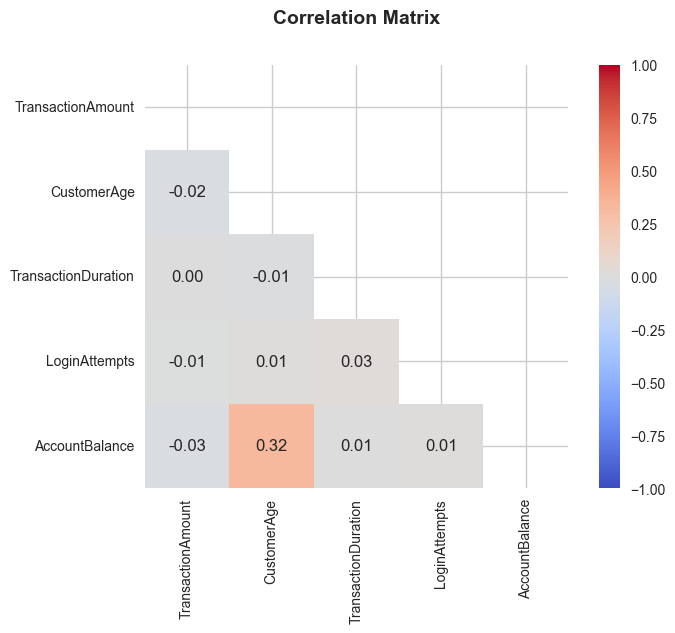

In [5]:
# Menampilkan korelasi antar kolom

# Pilih kolom numerik saja
numerical_cols = df.select_dtypes(include=['number']).columns

# Hitung matriks korelasi
corr = df[numerical_cols].corr()

# Buat tampilan lower triangel
mask = np.triu(np.ones_like(corr, dtype=bool))

# Visualisasi heatmap
fig, ax = plt.subplots()
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    vmin=-1,
    vmax=1,
    square=True
)
ax.set_title('Correlation Matrix', size=14, pad=30, weight='bold')
plt.show()

<p style="text-align: justify; text-indent: 2em;">
Hasil visualisasi diatas, korelasi tertinggi berada diangka 0.32 (korelasi positif lemah), yaitu kolom/fitur <code>AccountBalance</code> dengan <code>CustomerAge</code>. Artinya terdapat hubungan positif lemah antara usia customer dan saldo rekening. Semakin tinggi usia customer, terdapat kecenderungan saldo rekening juga meningkat, meskipun hubungan tersebut tidak kuat. Sedangkan untuk fitur numerik lainnya memiliki nilai yang sangat rendah (mendekati 0) yang menunjukkan sebagian besar fitur numerik relatif independen satu sama lain.
</p>

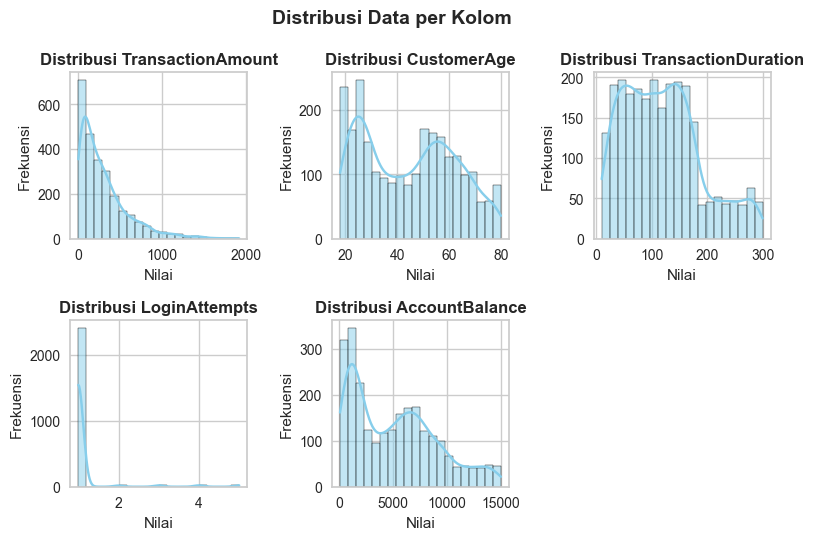

In [6]:
# Menampilkan histogram untuk semua kolom numerik

fig, axes = plt.subplots(2, 3)
axes = axes.flatten()

for idx, column in enumerate(numerical_cols):
    sns.histplot(
        df[column],
        bins=20,
        kde=True,
        color='skyblue',
        ax=axes[idx]
    ),
    axes[idx].set_title(f'Distribusi {column}', weight='bold')
    axes[idx].set_xlabel('Nilai')
    axes[idx].set_ylabel('Frekuensi')

# Hapus subplot yang tidak digunakan
for idx in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Distribusi Data per Kolom', size=14, weight='bold')
plt.tight_layout()
plt.show()

<p style="text-align: justify; text-indent: 2em;">
Berdasarkan histogram di atas, sebagian besar fitur numerik tidak mengikuti distribusi normal. Fitur <code>TransactionAmount</code> dan <code>LoginAttempts</code> menunjukkan pola <i>right skewed</i> (condong ke kanan), sedangkan <code>CustomerAge</code>, <code>TransactionDuration</code>, dan <code>AccountBalance</code> memiliki distribusi yang tidak simetris dengan lebih dari satu puncak (<i>multimodal</i>). Hal ini menunjukkan bahwa karakteristik distribusi setiap fitur numerik berbeda-beda.
</p>

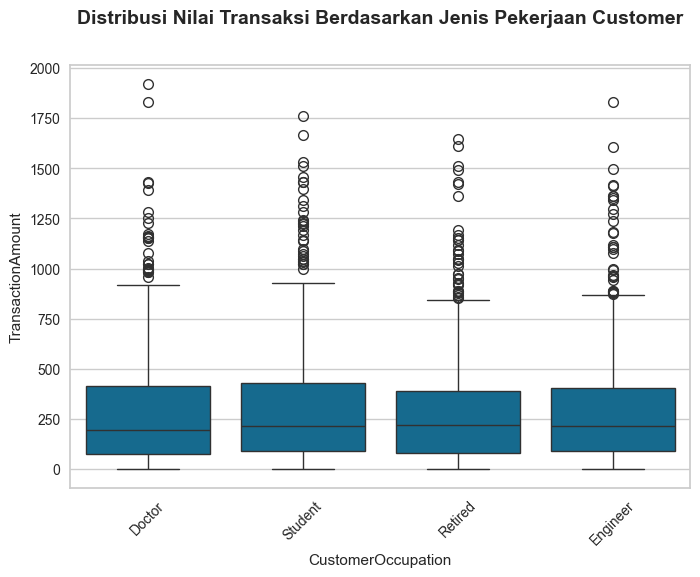

In [7]:
# Visualisasi boxplot (mengetahui hubungan tingkat transaksi dengan pekerjaan)
fig, ax = plt.subplots()
sns.boxplot(
    x='CustomerOccupation',
    y='TransactionAmount',
    data=df
)
ax.set_title('Distribusi Nilai Transaksi Berdasarkan Jenis Pekerjaan Customer', weight='bold', size=14, pad=30)
plt.xticks(rotation=45)
plt.show()

<p style="text-align: justify; text-indent: 2em;">
Boxplot merupakan visualisasi yang digunakan untuk melihat distribusi data, nilai median, sebaran data berdasarkan kuartil, serta mengidentifikasi adanya <i>outlier</i>. Berdasarkan visualisasi di atas, seluruh kategori <code>CustomerOccupation</code> memiliki nilai <code>TransactionAmount</code> yang mengandung <i>outlier</i>, ditunjukkan oleh titik-titik yang berada di luar batas whisker.
</p>

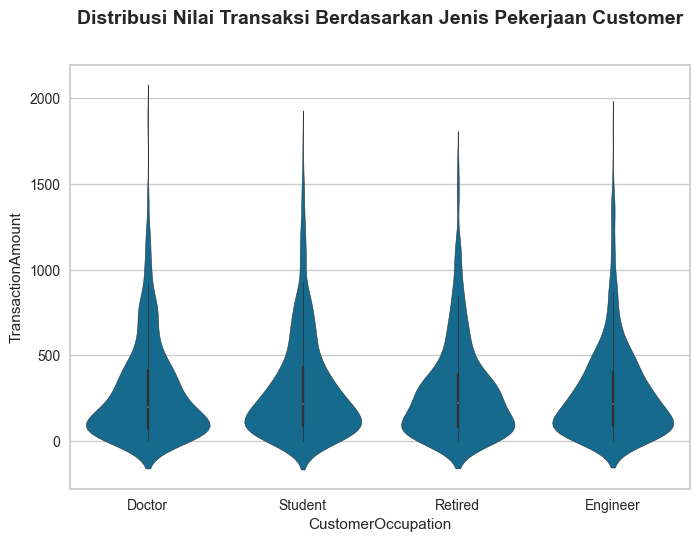

In [8]:
# Visualisasi violin plot
plt.figure()
sns.violinplot(
    x='CustomerOccupation',
    y='TransactionAmount',
    data=df,
)
plt.title('Distribusi Nilai Transaksi Berdasarkan Jenis Pekerjaan Customer', size=14, weight='bold', pad=30)
plt.show()

<p style="text-align: justify; text-indent: 2em;">
Violin plot merupakan visualisasi yang menampilkan distribusi data sekaligus kepadatan (density) setiap kelompok kategori. Semakin lebar bentuk violin semakin banyak data yang berada pada rentang tersebut. Berdasarkan keempat kategori <code>CustomerOccupation</code> memiliki pola distribusi <code>TransactionAmount</code> yang relatif serupa. Sebagian besar transaksi terkonsentrasi pada nilai transaksi yang rendah, sendangkan transaksi dengan nominalyang tinggi jumlahnya relatif sedikit. Selain itu, tidak terlihat adanya perbedaan distribusi yang signifikan antara jenis pekerjaan customer
</p>

# **4. Data Cleaning & Data Preprocessing**

### **4.1 Handling Missing Value**

In [9]:
# Cek jumlah nilai kosong setiap kolom
df.isnull().sum()

TransactionID              29
AccountID                  21
TransactionAmount          26
PreviousTransactionDate    28
TransactionType            30
Location                   30
DeviceID                   30
IP Address                 20
MerchantID                 23
Channel                    27
CustomerAge                18
CustomerOccupation         23
TransactionDuration        26
LoginAttempts              21
AccountBalance             27
TransactionDate            24
dtype: int64

In [10]:
# Cek jumlah data duplikat
df.duplicated().sum()

np.int64(21)

In [11]:
# Hapus nilai kosong
df.dropna(inplace=True)

# Cek ulang
df.isnull().sum()

TransactionID              0
AccountID                  0
TransactionAmount          0
PreviousTransactionDate    0
TransactionType            0
Location                   0
DeviceID                   0
IP Address                 0
MerchantID                 0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
AccountBalance             0
TransactionDate            0
dtype: int64

In [12]:
# Hapus data duplikat
df.drop_duplicates(inplace=True)

# Cek ulang
df.duplicated().sum()

np.int64(0)

In [13]:
# Hapus kolom Date, id, dan IP Address

# Ambil kolom yang akan dihapus
cols_to_drop = [
    col for col in df.columns if
    'id' in col.lower() or
    'ip' in col.lower() or
    'date' in col.lower()
]

print(f'Jumlah kolom sebelum dihapus : {df.shape[1]} ')

# Gunakan .drop() untuk menghapus kolom di cols_to_drop
df = df.drop(columns=cols_to_drop)

print(f'Jumlah kolom setelah dihapus : {df.shape[1]} ')

df.head()

Jumlah kolom sebelum dihapus : 16 
Jumlah kolom setelah dihapus : 9 


,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,14.09,Debit,San Diego,ATM,70.0,Doctor,81.0,1.0,5112.21
1,376.24,Debit,Houston,ATM,68.0,Doctor,141.0,1.0,13758.91
2,126.29,Debit,Mesa,Online,19.0,Student,56.0,1.0,1122.35
3,184.50,Debit,Raleigh,Online,26.0,Student,25.0,1.0,8569.06
5,92.15,Debit,Oklahoma City,ATM,18.0,Student,172.0,1.0,781.68


In [14]:
# Feature encoding untuk fitur kategorik

# Pilih kolom kategorik
categorical_cols = (df.select_dtypes(include=['object', 'string']).columns.tolist())

encoders = {}

# Masukkan kolom kategorik ke encoders
for column in categorical_cols:
    label_encoder = LabelEncoder()
    df[column] = label_encoder.fit_transform(df[column])
    encoders[column] = label_encoder

df.head()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,14.09,1,36,0,70.0,0,81.0,1.0,5112.21
1,376.24,1,15,0,68.0,0,141.0,1.0,13758.91
2,126.29,1,23,2,19.0,3,56.0,1.0,1122.35
3,184.50,1,33,2,26.0,3,25.0,1.0,8569.06
5,92.15,1,28,0,18.0,3,172.0,1.0,781.68


In [15]:
# Cek ulang kolom yang ada
print(f'Jumlah kolom : {df.shape[1]}\n')
print(f'List kolom   :\n{df.columns.tolist()} ')

Jumlah kolom : 9

List kolom   :
['TransactionAmount', 'TransactionType', 'Location', 'Channel', 'CustomerAge', 'CustomerOccupation', 'TransactionDuration', 'LoginAttempts', 'AccountBalance'] 


### **4.2 Handling Outlier (menggunakan IQR)**

In [16]:
print(' SEBELUM HANDLING OUTLIER '.center(70, '='))
display(df.describe())

# Handling outlier
for col in numerical_cols:
    # Rumus
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    # Tentukan lower dan upper bound
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Simpan ke df yang memnuhi lower dan upper bound
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print('\n\n')
print(' SETELAH HANDLING OUTLIER '.center(70, '='))
df.describe()

====================== SEBELUM HANDLING OUTLIER ======================


,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
count,2135.000000,2135.000000,2135.000000,2135.000000,2135.000000,2135.000000,2135.000000,2135.000000,2135.000000
mean,298.096178,0.773302,21.251991,0.978923,44.622951,1.503044,120.152693,1.117564,5093.583789
std,290.962542,0.418794,12.302811,0.807083,17.835201,1.135961,70.862964,0.578225,3919.681355
min,0.260000,0.000000,0.000000,0.000000,18.000000,0.000000,10.000000,1.000000,102.200000
25%,83.045000,1.000000,11.000000,0.000000,27.000000,0.000000,63.000000,1.000000,1482.350000
50%,213.330000,1.000000,21.000000,1.000000,45.000000,1.000000,113.000000,1.000000,4638.370000
75%,414.630000,1.000000,32.000000,2.000000,59.000000,3.000000,162.000000,1.000000,7696.920000
max,1831.020000,1.000000,42.000000,2.000000,80.000000,3.000000,300.000000,5.000000,14977.990000





====================== SETELAH HANDLING OUTLIER ======================


,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
count,1945.000000,1945.000000,1945.000000,1945.000000,1945.000000,1945.000000,1945.000000,1945.0,1945.000000
mean,256.838278,0.771722,21.299743,0.977378,44.693059,1.503342,119.225193,1.0,5100.811913
std,218.370197,0.419830,12.329250,0.804119,17.743453,1.135888,70.600647,0.0,3907.153333
min,0.260000,0.000000,0.000000,0.000000,18.000000,0.000000,10.000000,1.0,102.200000
25%,78.920000,1.000000,11.000000,0.000000,27.000000,0.000000,63.000000,1.0,1488.650000
50%,199.700000,1.000000,21.000000,1.000000,45.000000,1.000000,111.000000,1.0,4693.600000
75%,374.500000,1.000000,32.000000,2.000000,59.000000,3.000000,162.000000,1.0,7659.990000
max,903.190000,1.000000,42.000000,2.000000,80.000000,3.000000,300.000000,1.0,14977.990000


<p style="text-align: justify; text-indent: 2em;">
Terdapat beberapa prubahan data jika ditinjau dari satistik deskriptif.  Setelah dilakukan handling outlier total baris dari 2.135 menjadi 1.954 atau 190 baris yang dihapus karena dianggap outlier. Selain itu, terdapat juga bebrapa perubahan jumlah nilai baris pada setiap kolom yang dapat anda analisis sendiri.
</p>

### 4.3 **Feature Scaling menggunakan StandardScaler() (Z-score)**

In [17]:
# Scaling untuk data numerik

print(' SEBELUM SCALING '.center(70, '='))

display(df.head())

print('\n\n')
print(' SETELAH SCALING '.center(70, '='))

scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

df.head()

========================== SEBELUM SCALING ===========================


,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,14.09,1,36,0,70.0,0,81.0,1.0,5112.21
1,376.24,1,15,0,68.0,0,141.0,1.0,13758.91
2,126.29,1,23,2,19.0,3,56.0,1.0,1122.35
3,184.50,1,33,2,26.0,3,25.0,1.0,8569.06
5,92.15,1,28,0,18.0,3,172.0,1.0,781.68





========================== SETELAH SCALING ===========================


,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,-1.111922,1,36,0,1.426636,0,-0.541568,0.0,0.002918
1,0.546926,1,15,0,1.313889,0,0.308502,0.0,2.216531
2,-0.597984,1,23,2,-1.448403,3,-0.895763,0.0,-1.018513
3,-0.331350,1,33,2,-1.053790,3,-1.334965,0.0,0.887895
5,-0.754364,1,28,0,-1.504776,3,0.747704,0.0,-1.105726


<p style="text-align: justify; text-indent: 2em;">
Setelah dilakukan proses standardisasi menggunakan StandardScaler, setiap fitur numerik diubah menggunakan metode Z-score. Proses ini membuat rata-rata (mean) setiap fitur menjadi 0 dan standar deviasi (standard deviation) menjadi 1. Nilai hasil standardisasi dapat bernilai negatif, nol, maupun positif. Nilai negatif menunjukkan data berada di bawah rata-rata, nilai nol menunjukkan data berada tepat pada rata-rata, sedangkan nilai positif menunjukkan data berada di atas rata-rata.
</p>

### **4.4 Data Binning**

In [18]:
print(' SEBELUM DATA BINNING '.center(70, '='))
display(df.head())

# Tentukan kolom numerik yang akan dikelompokkan
age_col_to_bin = 'CustomerAge'
new_age_col = 'CustomerAgeGroup'

# Tentukan label
age_bin_labels = ['Rendah', 'Sedang', 'Tinggi']

# Bagi data menjadi 3 kelompok menggunakan .qcut()
df[new_age_col] = pd.qcut(
    df[age_col_to_bin],
    q=3,
    labels=age_bin_labels,
    duplicates='drop'
)

# Label encoding pada kolom baru supaya menjadi numerik
label_encoder = LabelEncoder()
df[new_age_col] = label_encoder.fit_transform(df[new_age_col])

# Simpan hasil encoder ke categorical_cols
encoders[new_age_col] = label_encoder
categorical_cols.extend([new_age_col])

print('\n\n')
print(' SETELAH DATA BINNING '.center(70, '='))

df.head()

======================== SEBELUM DATA BINNING ========================


,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,-1.111922,1,36,0,1.426636,0,-0.541568,0.0,0.002918
1,0.546926,1,15,0,1.313889,0,0.308502,0.0,2.216531
2,-0.597984,1,23,2,-1.448403,3,-0.895763,0.0,-1.018513
3,-0.331350,1,33,2,-1.053790,3,-1.334965,0.0,0.887895
5,-0.754364,1,28,0,-1.504776,3,0.747704,0.0,-1.105726





======================== SETELAH DATA BINNING ========================


,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,CustomerAgeGroup
0,-1.111922,1,36,0,1.426636,0,-0.541568,0.0,0.002918,2
1,0.546926,1,15,0,1.313889,0,0.308502,0.0,2.216531,2
2,-0.597984,1,23,2,-1.448403,3,-0.895763,0.0,-1.018513,0
3,-0.331350,1,33,2,-1.053790,3,-1.334965,0.0,0.887895,0
5,-0.754364,1,28,0,-1.504776,3,0.747704,0.0,-1.105726,0


<p style="text-align: justify; text-indent: 2em;">
Bining data bertujuan untuk menyederhanakan data supaya model Machine Learing dapat belajar dan menangkap pola data berdasarkan cluster dan bukan berdasarkan nilai individu dari datanya. Pada output setelah dilakukan Bining data, terdapat nama kolom baru yaitu <code>CustomerAgeGroup</code>. Hasil bining data alangkah baiknya dimasukkan ke kolom yang baru supaya nilai usia yang asli tidak hilang
</p>

# **5. Membangun Model Clustering**

<p style="text-align: justify; text-indent: 2em;">
Pada tahap ini kita akan menggunakan algoritma <code>K-Means Clustering</code> yang cocok untuk pengklasifikasian data berdasarkan cluster atau kelompok-kelompok tertentu.
</p>

In [19]:
# Copy data yang sudah clean supay tidak tertimpa
df_clean = df.copy()
df_clean.describe()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,CustomerAgeGroup
count,1.945000e+03,1945.000000,1945.000000,1945.000000,1.945000e+03,1945.000000,1.945000e+03,1945.0,1.945000e+03,1945.000000
mean,-8.402305e-17,0.771722,21.299743,0.977378,-1.269479e-16,1.503342,2.557223e-17,0.0,-6.027740e-17,0.983548
std,1.000257e+00,0.419830,12.329250,0.804119,1.000257e+00,1.135888,1.000257e+00,0.0,1.000257e+00,0.819475
min,-1.175271e+00,0.000000,0.000000,0.000000,-1.504776e+00,0.000000,-1.547483e+00,0.0,-1.279678e+00,0.000000
25%,-8.149648e-01,1.000000,11.000000,0.000000,-9.974163e-01,0.000000,-7.965883e-01,0.0,-9.247374e-01,0.000000
50%,-2.617251e-01,1.000000,21.000000,1.000000,1.730327e-02,1.000000,-1.165330e-01,0.0,-1.042490e-01,1.000000
75%,5.389562e-01,1.000000,32.000000,2.000000,8.065296e-01,3.000000,6.060257e-01,0.0,6.551666e-01,2.000000
max,2.960651e+00,1.000000,42.000000,2.000000,1.990369e+00,3.000000,2.561185e+00,0.0,2.528623e+00,2.000000


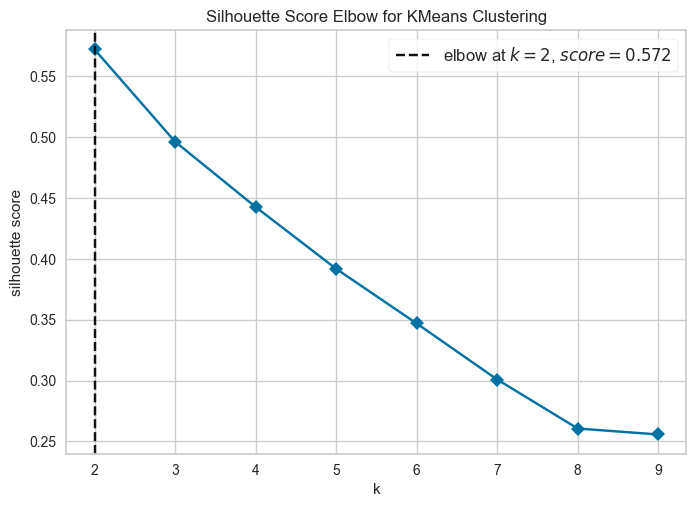

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [20]:
# Visualisasi Elbow Method dengan KElbowVissializer()

# Buat model clustering dengan KMeans()
model = KMeans(random_state=42)

# Buat KElbowVisualizer
kelbow_visualizer = KElbowVisualizer(
    model,
    k=(2, 10),
    metric="silhouette",
    timings=False
)

kelbow_visualizer.fit(df_clean) # Latih data
kelbow_visualizer.show()       # Tampilkan visualisasi

<p style="text-align: justify; text-indent: 2em;">
Visualisasi KElbowVisualizer menggunakan metrik Silhouette Score, diperoleh nilai Sihouette tertinggi sebesar 0,572 pada k=2. Hal ini menunjukkan pembagian data menjadi 2 cluster. Sihouette score diatas 0,5 mengindikasikan bahwa struktur cluster yang terbentuk cukup baik, dimana objek dalam setiap clustr memiliki tingkat kemiripan yag tinggi dan pemisahan yang cukup jelas terhadap cluster lainnya.
</p>

In [21]:
# Menggunakan algoritma K-Means Clustering

model_kmeans = KMeans(n_clusters=2, random_state=42)
model_kmeans.fit(df_clean)

KMeans(n_clusters=2, random_state=42)

In [22]:
# Save model
joblib.dump(model_kmeans, 'models/model_clustering.h5')

['models/model_clustering.h5']

In [23]:
# Hitung dan tampilkan Silhouette Score

# Ambil hasil label cluster dari model kmeans
cluster_labels = model_kmeans.labels_

# Hitung Silhouette score
silhouette_avg  = silhouette_score(df_clean, cluster_labels)

print('Silhouette score : ', silhouette_avg)

Silhouette score :  0.572159925838334


<p style="text-align: justify; text-indent: 2em;">
Setelah model K-Means dibangung menggunakan jumlah cluster optimal (2 cluster), dilakukan evaluasi menggunakan Silhouette score yang menunjukkan angka 0,572. Angka ini konsisten dengan hasil Score Elbow
</p>

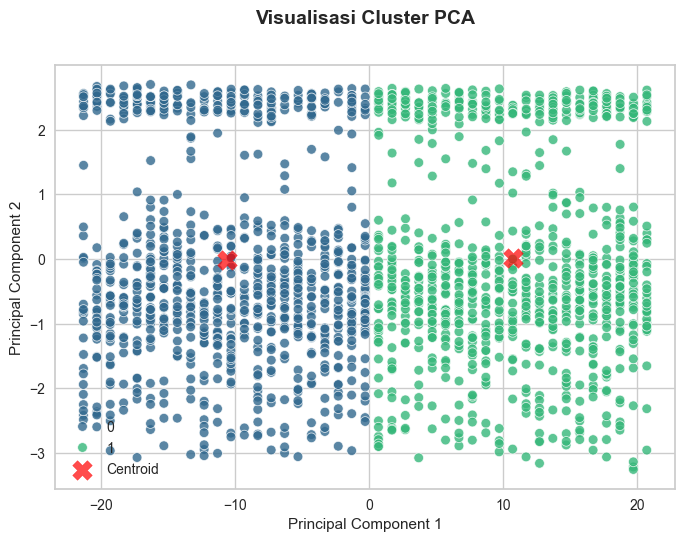

In [24]:
# Visualisasi PCA hasil clustering


pca = PCA(n_components=2)             # PCA menjadi 2 dimensi
df_pca = pca.fit_transform(df_clean)  # Latih data
df_pca = pd.DataFrame(
    data=df_pca,
    columns=['Principal Component 1', 'Principal Component 2']
)

# Tambahkan kolom 'Cluster' ke df_pca
df_pca['Cluster'] = cluster_labels

# Visualisasi scatter plot
fig, ax = plt.subplots()
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Cluster',
    palette=sns.color_palette('viridis', n_colors=2),
    data=df_pca,
    legend='full',
    alpha=0.8
)

ax.set_title('Visualisasi Cluster PCA', fontsize=14, weight='bold', pad=30)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

centers_df = pd.DataFrame(
    model_kmeans.cluster_centers_,
    columns=df_clean.columns
)

centers = pca.transform(centers_df)

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    c='red',
    s=200,
    alpha=0.7,
    marker='X',
    label='Centroid'
)
plt.legend()
plt.show()

<p style="text-align: justify; text-indent: 2em;">
Visualisasi Cluster PCA diatas memberikan informasi bahwa Silhouette score = 0,572 sudah konsisten. Kedua cluster memiliki pemisah yang cukup baik, kemudian tanda x merupakan central dari masing-masing cluster
</p>

In [25]:
# Membangun model Kmeans menggunakan data yang sudah direduksi menjadi 2 dimensi

pca = PCA(n_components=2)                   # Ubah jadi 2 dimensi
df_pca_array = pca.fit_transform(df_clean)  # latih data

data_final = pd.DataFrame(data=df_pca_array, columns=['PCA1', 'PCA2'])
kmeans_pca = KMeans(n_clusters=2, random_state=42) # Model KMeans baru
kmeans_pca.fit(data_final)                         # Latih data

KMeans(n_clusters=2, random_state=42)

In [26]:
# Save model
joblib.dump(kmeans_pca, 'models/pca_model_clustering.h5')

['models/pca_model_clustering.h5']

# **5. Interpretasi Cluster**

In [30]:
# Tambahkan kolom 'Cluster' ke 'cluster_lables'
df_clean['Cluster'] = cluster_labels

# Ringkasan statistik tiap cluster
agg_summary = (
    df_clean
    .groupby('Cluster')[numerical_cols]
    .agg(['mean', 'min', 'max'])
    .round(2)
    .T
)

display(agg_summary)

Cluster                      0     1
TransactionAmount   mean -0.01  0.01
                    min  -1.17 -1.18
                    max   2.96  2.90
CustomerAge         mean  0.02 -0.02
                    min  -1.50 -1.50
                    max   1.99  1.99
TransactionDuration mean  0.03 -0.03
                    min  -1.55 -1.55
                    max   2.56  2.55
LoginAttempts       mean  0.00  0.00
                    min   0.00  0.00
                    max   0.00  0.00
AccountBalance      mean  0.01 -0.01
                    min  -1.28 -1.28
                    max   2.52  2.53

<p style="text-align: justify; text-indent: 2em;">
Cluster 0 memiliki nilai mean yang sangat dengan dengan nol setelah StandardScaler. Hal ini menunjukkan karakteristik customer relatif mendekati mean populasi. Secara umum, cluster ini merepresentasikan customer dengan transaksi yang cenderung normal.
</p>

<p style="text-align: justify; text-indent: 2em;">
Cluster 1 memiliki nilai mean yang sama mendekati nol. Dengan demikian cluster ini dapat diinterpretasikan sebagai kelompok customer dengan pola transaksi yang relatif serupa dengan populasi secara umum, namun memiliki kecenderungan melakukan transaksi dengan nilai sedikit lebih tinggi dan durasi yang lebih singkat.
</p>

# **6. Mengeksport Data**

In [33]:
# Ubah nama kolom 'Cluster' menjadi 'Target'
df_clean.rename(columns={'Cluster': 'Target'}, inplace=True)
df_clean.head()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,CustomerAgeGroup,Target
0,-1.111922,1,36,0,1.426636,0,-0.541568,0.0,0.002918,2,1
1,0.546926,1,15,0,1.313889,0,0.308502,0.0,2.216531,2,0
2,-0.597984,1,23,2,-1.448403,3,-0.895763,0.0,-1.018513,0,1
3,-0.331350,1,33,2,-1.053790,3,-1.334965,0.0,0.887895,0,1
5,-0.754364,1,28,0,-1.504776,3,0.747704,0.0,-1.105726,0,1


In [34]:
# Save data
df_clean.to_csv('dataset/data_clustering.csv', index=False)

In [35]:
# Inverse dataset ke rentang normal untuk numeric

# Copy df_clean
df_inverse = df_clean.copy()

# Gunakan 'scaler' untuk mengembalikan 'numerical_cols' ke nlai asli
df_inverse[numerical_cols] = scaler.inverse_transform(df_inverse[numerical_cols])

df_inverse.head()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,CustomerAgeGroup,Target
0,14.09,1,36,0,70.0,0,81.0,1.0,5112.21,2,1
1,376.24,1,15,0,68.0,0,141.0,1.0,13758.91,2,0
2,126.29,1,23,2,19.0,3,56.0,1.0,1122.35,0,1
3,184.50,1,33,2,26.0,3,25.0,1.0,8569.06,0,1
5,92.15,1,28,0,18.0,3,172.0,1.0,781.68,0,1


In [36]:
# Inverse dataset yang sudah diencode ke kategori aslinya
for column in categorical_cols:
    encoder = encoders[column]
    df_inverse[column] = encoder.inverse_transform(df_inverse[column].astype(int))

df_inverse.head()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,CustomerAgeGroup,Target
0,14.09,Debit,San Diego,ATM,70.0,Doctor,81.0,1.0,5112.21,Tinggi,1
1,376.24,Debit,Houston,ATM,68.0,Doctor,141.0,1.0,13758.91,Tinggi,0
2,126.29,Debit,Mesa,Online,19.0,Student,56.0,1.0,1122.35,Rendah,1
3,184.50,Debit,Raleigh,Online,26.0,Student,25.0,1.0,8569.06,Rendah,1
5,92.15,Debit,Oklahoma City,ATM,18.0,Student,172.0,1.0,781.68,Rendah,1


In [43]:
# Analisis deskripsi dataset hasil inverse

agg_summary_num = (
    df_inverse
    .groupby('Target')[numerical_cols]
    .agg(['mean', 'min', 'max'])
    .round(2)
    .T
)

agg_summary_cat = (
    df_inverse
    .groupby('Target')[categorical_cols]
    .agg(lambda x: x.mode()[0])
    .round(2)
    .T
)

print(' NUMERICAL_COLS '.center(70, '='))
display(agg_summary_num)

print()

print(' CATEGORICAL_COLS '.center(70, '='))
display(agg_summary_cat)

=========================== NUMERICAL_COLS ===========================


Target                           0         1
TransactionAmount   mean    255.55    258.15
                    min       0.32      0.26
                    max     903.19    889.01
CustomerAge         mean     45.06     44.33
                    min      18.00     18.00
                    max      80.00     80.00
TransactionDuration mean    121.12    117.30
                    min      10.00     10.00
                    max     300.00    299.00
LoginAttempts       mean      1.00      1.00
                    min       1.00      1.00
                    max       1.00      1.00
AccountBalance      mean   5142.17   5058.81
                    min     117.98    102.20
                    max   14942.78  14977.99


========================== CATEGORICAL_COLS ==========================


Target,0,1
TransactionType,Debit,Debit
Location,Charlotte,Tucson
Channel,Branch,Branch
CustomerOccupation,Doctor,Student
CustomerAgeGroup,Sedang,Rendah


<p style="text-align: justify; text-indent: 2em;">
Cluster 0 merepresentasikan pelanggan dengan usia rata-rata sekitar 45 tahun, memiliki saldo akun yang relatif lebih tinggi, serta durasi transaksi yang sedikit lebih lama dibandingkan cluster lainnya. Mayoritas pelanggan dalam cluster ini melakukan transaksi Debit, menggunakan Branch sebagai kanal transaksi, berasal dari Charlotte, dan banyak berprofesi sebagai Doctor. Berdasarkan pengelompokan usia, sebagian besar pelanggan berada pada kategori Sedang.
</p>

<p style="text-align: justify; text-indent: 2em;">
Cluster 1 menggambarkan pelanggan dengan usia rata-rata sekitar 44 tahun, nilai transaksi yang sedikit lebih tinggi, namun memiliki saldo akun dan durasi transaksi yang sedikit lebih rendah dibandingkan Cluster 0. Mayoritas pelanggan menggunakan transaksi Debit melalui Branch, berasal dari Tucson, serta didominasi oleh pelanggan dengan profesi Student. Berdasarkan hasil binning usia, kelompok ini lebih banyak berada pada kategori usia Rendah.
</p>

<p style="text-align: justify; text-indent: 2em;">
Ini konsisten dengan Silhouette Score sekitar 0,572, yang menunjukkan bahwa data memang dapat dipisahkan menjadi dua cluster dengan kualitas yang cukup baik, tetapi karakteristik rata-rata kedua cluster masih cukup mirip. Perbedaan yang paling mencolok justru terlihat pada fitur kategorikal, seperti lokasi (Charlotte vs Tucson), profesi (Doctor vs Student), dan kelompok usia (Sedang vs Rendah), yang memberikan identitas masing-masing cluster.
</p>

In [44]:
# Simpan data inverse
df_inverse.to_csv('dataset/data_clustering_inverse.csv', index=False)